# 量子四则运算

## 量子加法器

量子加法是最基本的算术操作之一，在很多量子算法中都起着核心作用。这些量子加法器使用量子比特代替经典比特，并通过量子门（如CNOT门和Toffoli门）来实施逻辑运算。

量子加法器包含了两种子量子线路模块 MAJ 和 UMA ，作用分别是获得当前二进制位的进位数值和当前二进制位的结果数值。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/2_10_0001.png" width="40%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>


### MAJ量子线路

MAJ（Majority）量子线路是量子加法器中用于计算进位的基本组件。它主要负责根据当前位的输入值（前一位的进位值和两个加数的当前位值）计算出新的进位值和中间结果，以供后续计算使用。下面详细解释MAJ模块的功能和工作原理。

#### MAJ模块的输入输出

MAJ量子线路的输入包括：
- 前一位的进位值 $c_i$
- 当前位的两个待加值 $a_i$ 和 $b_i$

输出为：
- $(a_i + c_i) \mod 2$
- $(a_i + b_i) \mod 2$
- 当前位的新进位值 $c_{i+1}$

#### MAJ的工作原理

MAJ模块的主要任务是计算进位 $c_{i+1}$，这一计算基于三个输入值 $a_i$, $b_i$ 和 $c_i$。进位 $c_{i+1}$ 可通过以下逻辑得到：

$
c_{i+1} = (a_i \land b_i) \lor (b_i \land c_i) \lor (a_i \land c_i)
$

这表示 $c_{i+1}$ 为真（即1）当且仅当至少两个输入值为真。

#### 枚举 $a_i$ 的情况

当我们详细考虑 $a_i$ 的可能值时，可以进一步简化计算过程：

1. 当 $a_i = 0$ 时，进位 $c_{i+1}$ 可以表示为：
$
   c_{i+1} = b_i \land c_i
$
   因为进位只在 $b_i$ 和 $c_i$ 同时为1时发生。

2. 当 $a_i = 1$ 时，进位 $c_{i+1}$ 可以表示为：
$
   c_{i+1} = (b_i \land c_i) \lor (b_i \lor c_i)
$
   这表示如果 $b_i$ 或 $c_i$ 中至少有一个为1，进位就会发生。

#### 量子逻辑门的应用

为了实现这些逻辑操作，MAJ模块通常利用量子逻辑门如CNOT门和Toffoli门：

- **CNOT门**：用于计算 $(a_i + b_i) \mod 2$ 和 $(a_i + c_i) \mod 2$，即模2加法。
- **Toffoli门**：用于计算 $c_{i+1}$，确保当且仅当两个输入中的至少两个为1时输出1。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/2_10_0002.png" width="40%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>


#### MAJ的代码实现

In [ ]:
import deepquantum as dq


def maj(cir, ci, bi, ai):
    """实现 MAJ 量子门，其中：

    ai, bi 是输入比特，
    ci 是用于存储计算进位结果的辅助比特。
    """
    # CNOT门获取 (a_i + b_i) mod 2，此结果暂存在 bi 中
    cir.cx(ai, bi)
    # CNOT门获取 (a_i + c_i) mod 2，此结果暂存在 ci 中
    cir.cx(ai, ci)
    # 使用Toffoli门计算新的进位值 c_{i+1} ，此结果暂存在 ai 中
    cir.ccx(bi, ci, ai)

    return cir

画出MAJ的量子线路

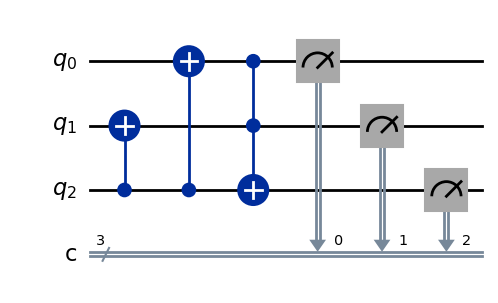

In [ ]:
cir = dq.QubitCircuit(3)

# 定义量子比特 a, b, c_in 在量子电路中的位置分别为量子比特 0, 1, 2
# 应用 MAJ 模块
cir = maj(cir, 0, 1, 2)

cir()
cir.measure()
cir.draw()

### UMA量子线路

UMA（UnMajority and Add）量子线路是量子加法器中用于恢复原始输入值并计算当前位结果的组件。它通常与MAJ（Majority）模块配合使用，MAJ模块用于生成进位和部分结果，而UMA模块则根据这些中间结果恢复原有的输入并得到最终的加法结果。下面详细解释UMA模块的功能和工作原理。

#### UMA模块的输入输出

UMA量子线路的输入包括：
- 由MAJ模块输出的 $(a_i + c_i) \mod 2$
- 由MAJ模块输出的 $(a_i + b_i) \mod 2$
- 当前位的进位值 $c_{i+1}$

输出为：
- 前一位的进位值 $c_i$
- 当前位的加法结果 $s_i = (a_i + b_i + c_i) \mod 2$
- 当前位的一个加数 $a_i$

#### UMA的工作原理

UMA模块的核心任务是通过反向逻辑恢复出 $a_i$ 和 $c_i$，并计算当前位的加法结果 $s_i$。这个过程可以分为以下几步：

1. **恢复 $a_i$**：
   - 利用Toffoli门的逆变换从 $c_{i+1}$ 恢复 $a_i$。因为在MAJ模块中，$c_{i+1}$ 是基于 $a_i$、$b_i$ 和 $c_i$ 的组合，所以通过适当的逆操作可以恢复出 $a_i$。

2. **恢复 $c_i$**：
   - 接着，使用CNOT门的逆变换（实际上CNOT门是自逆的，即其逆变换与自身相同）从 $(a_i + c_i) \mod 2$ 中恢复出 $c_i$。

3. **计算 $s_i$**：
   - 最后，已知 $(a_i + b_i) \mod 2$（即来自MAJ模块的输出），通过使用CNOT门将其与 $c_i$ 进行模2加法，从而得到 $s_i = (a_i + b_i + c_i) \mod 2$。

#### 量子逻辑门的应用

UMA模块使用以下量子逻辑门实现其功能：

- **Toffoli门**：逆Toffoli门用于从 $c_{i+1}$ 恢复 $a_i$。
- **CNOT门**：用于从 $(a_i + c_i) \mod 2$ 恢复 $c_i$，以及计算 $s_i$。

#### UMA的代码实现

In [ ]:
def uma(cir, ci, bi, ai):
    """实现 UMA 量子门，其中:

    ai, bi, ci 分别为输入的比特，
    ai 初始为 c_{i+1}（由MAJ模块计算得到的进位值），
    bi 初始为 (a_i + b_i) mod 2，
    ci 初始为 (a_i + c_i) mod 2。
    输出将 ai 复原为 a_i，ci 复原为 c_i，bi 更新为 s_i。
    """
    # 使用逆Toffoli门恢复 a_i，ai 恢复为 a_i
    cir.ccx(bi, ci, ai)
    # 使用CNOT门恢复 c_i，ci 恢复为 c_i
    cir.cx(ai, ci)
    # 使用CNOT门计算 (a_i + b_i + c_i) mod 2，结果存于 bi
    cir.cx(ci, bi)

    return cir

画出UMA的量子线路

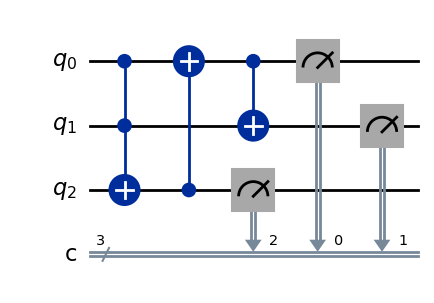

In [ ]:
cir = dq.QubitCircuit(3)

# 应用 UMA 模块
cir = uma(cir, 0, 1, 2)

cir()
cir.measure()
cir.draw()

## 合并线路

我们利用以上模块，制备量子加法器的线路

In [ ]:
def qadd(cir, a, b, c0):

    # 编码初态 a, b, c0
    if c0 == '1':
        cir.x(0)

    for i, s in enumerate(a[::-1]):
        if s == '1':
            cir.x(2 * i + 2)
    for i, s in enumerate(b[::-1]):
        if s == '1':
            cir.x(2 * i + 1)

    n = len(a)
    cir.barrier()
    for i in range(n):
        maj(cir, 2 * i, 2 * i + 1, 2 * i + 2)
        cir.barrier()

    cir.cx(len(a) + len(b) + len(c0) - 1, len(a) + len(b) + len(c0))

    for i in range(n - 1, -1, -1):
        cir.barrier()
        uma(cir, 2 * i, 2 * i + 1, 2 * i + 2)

    return cir

In [ ]:
# c0 为0或1，a，b的长度需相等
a = '100'
b = '001'
c0 = '1'

qubit_num = len(a) + len(b) + len(c0) + 1
cir = dq.QubitCircuit(qubit_num)
cir = qadd(cir, a, b, c0)

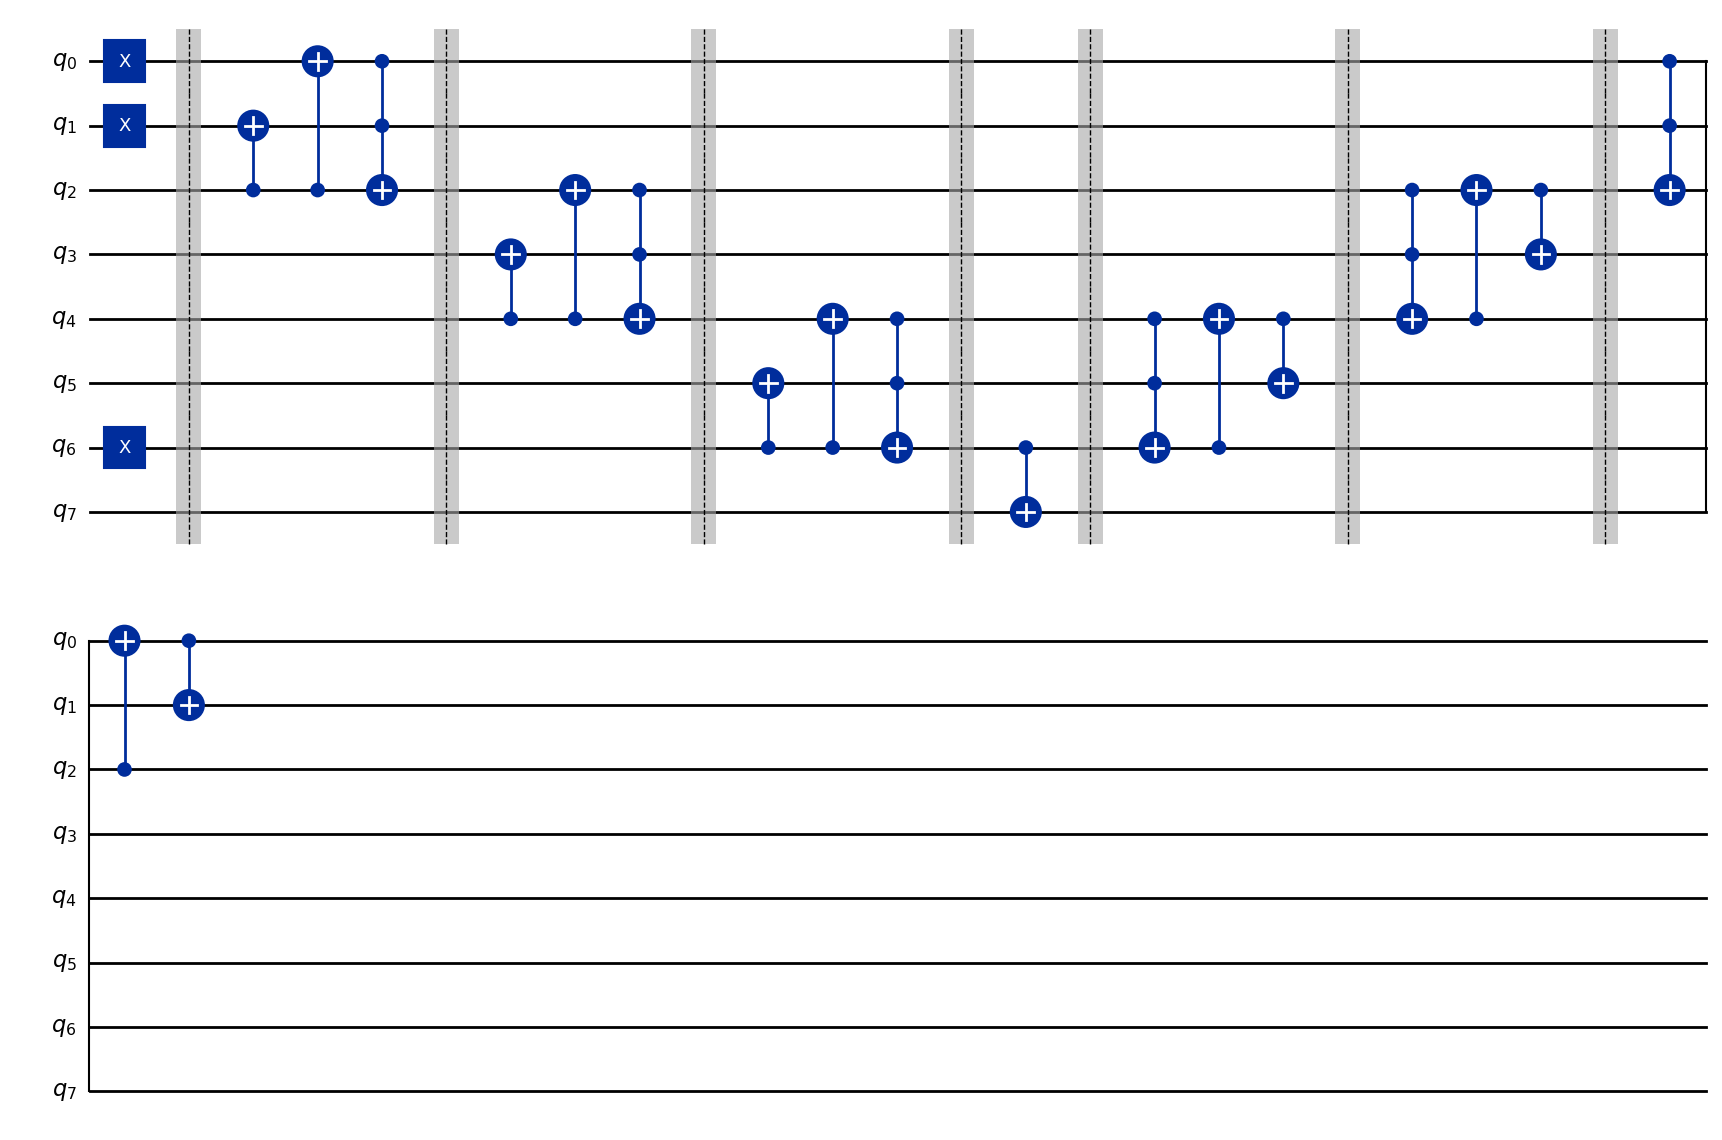

In [7]:
cir.draw()

In [8]:
cir()
res = cir.measure(wires=list(range(1, qubit_num, 2)))  # 打印测量结果

print('a=' + a)
print('b=' + b)
print('c0=' + c0)
print('a+b=' + list(res.keys())[0][::-1])

a=100
b=001
c0=1
a+b=0110


## 量子减法器

在传统的数字电路中，减法通常通过加法器来实现，其中一个被减数被转换为其补码，然后与另一个数相加。类似地，在量子计算中，量子减法器也通过将减法转换为加法来实现，但这涉及到量子位（qubits）的操作和量子门的使用。

### 补码在量子减法中的应用

在二进制系统中，一个数的补码通常用来表示负数。补码可以通过以下两个步骤获得：
1. **按位取反（One's Complement）**：将每个位上的0变为1，1变为0。
2. **加1（Two's Complement）**：在按位取反后的结果上加1。

在量子减法器中，如果我们想从数 $ A $ 中减去数 $ B $，我们可以将 $ B $ 转换为其补码，然后执行量子加法：
$ A - B = A + (-B) $

### 量子减法器的代码实现

In [ ]:
# 计算补码
def to_twos_complement(binary_str):
    # 计算位宽
    n = len(binary_str)

    # 计算补码：先取反，再加1
    inverted = ''.join('1' if x == '0' else '0' for x in binary_str)
    inverted_as_int = int(inverted, 2) + 1

    # 补码可能超出原始位宽，因此需要截取最后n位
    twos_complement = bin(inverted_as_int)[-n:]

    # 如果计算后的长度少于原始长度，需要在前面补零
    if len(twos_complement) < n:
        twos_complement = '0' * (n - len(twos_complement)) + twos_complement

    return twos_complement


def qsub(cir, a, b):

    b = to_twos_complement(b)
    # 编码初态 a, b,

    for i, s in enumerate(a[::-1]):
        if s == '1':
            cir.x(2 * i + 2)
    for i, s in enumerate(b[::-1]):
        if s == '1':
            cir.x(2 * i + 1)

    n = len(a)
    cir.barrier()
    for i in range(n):
        maj(cir, 2 * i, 2 * i + 1, 2 * i + 2)
        cir.barrier()

    cir.cx(len(a) + len(b), len(a) + len(b) + 1)

    for i in range(n - 1, -1, -1):
        cir.barrier()
        uma(cir, 2 * i, 2 * i + 1, 2 * i + 2)

    return cir

In [ ]:
# c0 为0或1，a，b的长度需相等
a = '111'
b = '011'

qubit_num = len(a) + len(b) + 2
cir = dq.QubitCircuit(qubit_num)
cir = qsub(cir, a, b)

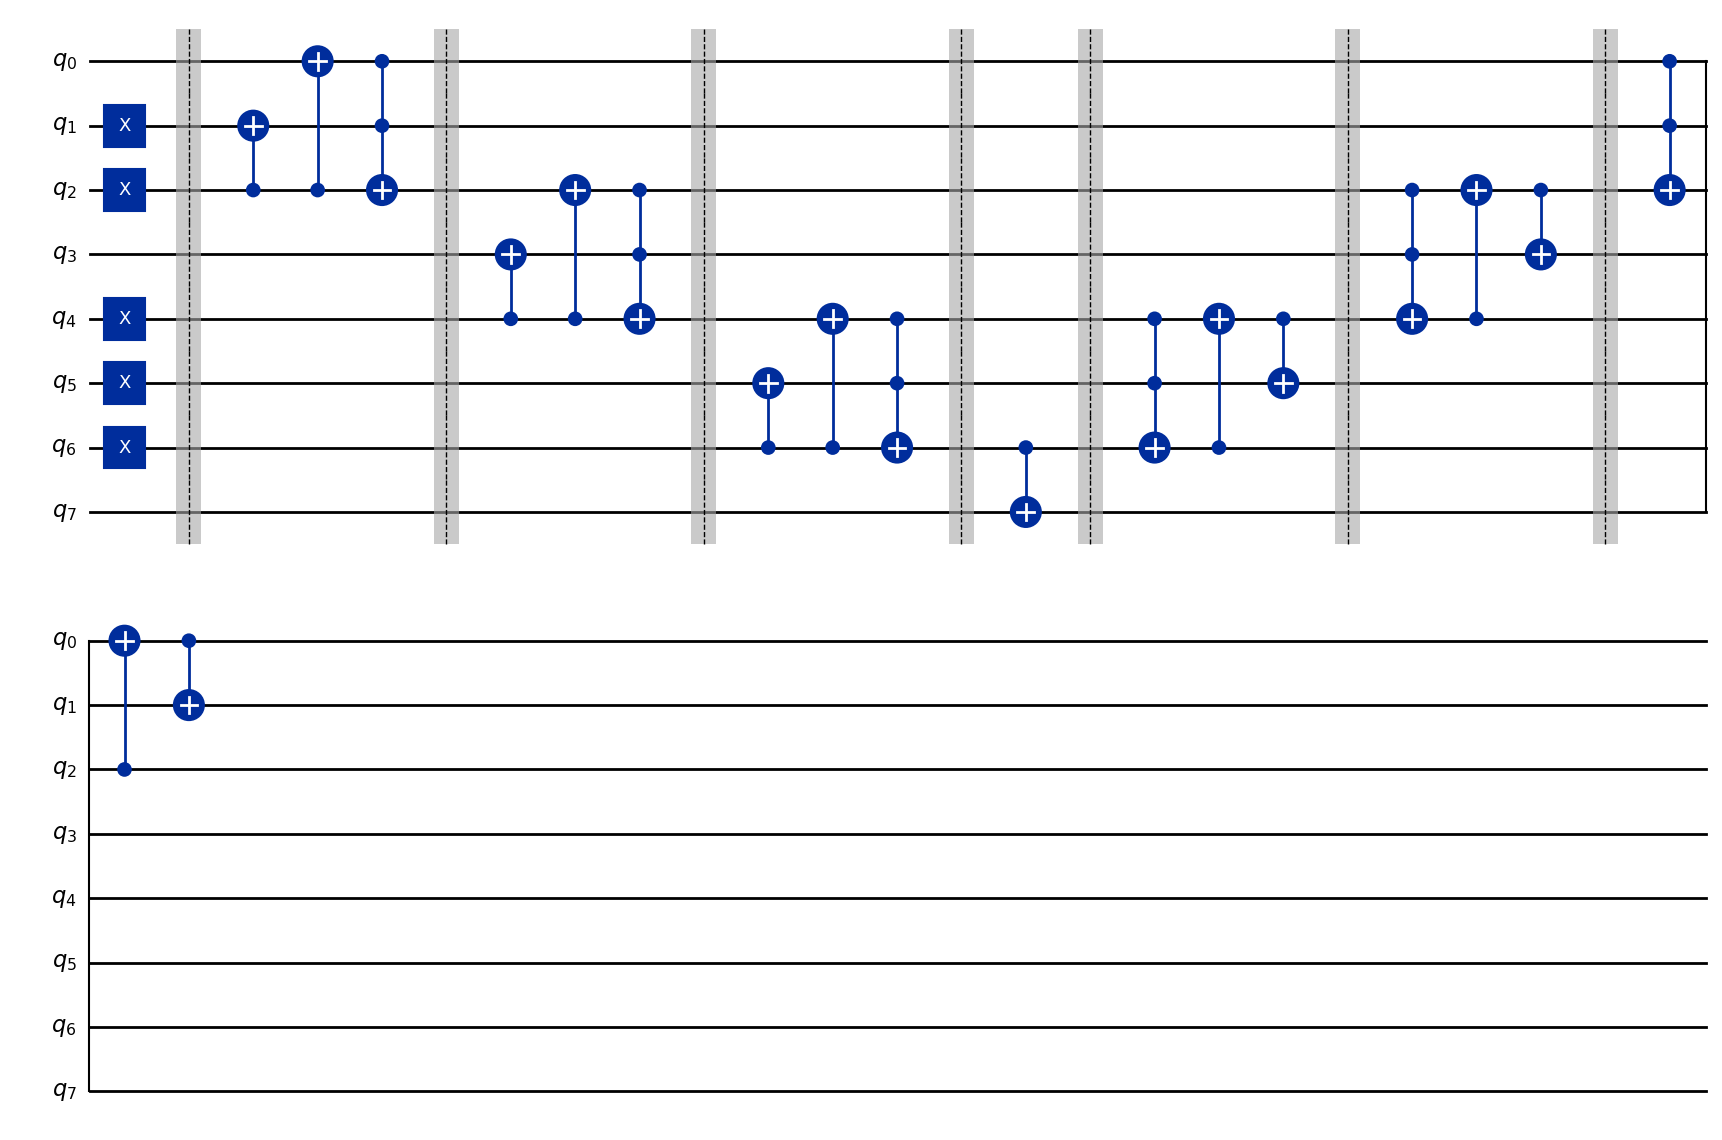

In [11]:
cir.draw()

In [12]:
cir()
res = cir.measure(wires=list(range(1, qubit_num - 1, 2)))  # 打印测量结果

print('a=' + a)
print('b=' + b)
print('a-b=' + list(res.keys())[0][::-1])

a=111
b=011
a-b=100


## 量子乘法器

量子乘法器是一种利用量子计算机的原理来实现乘法运算的机制。在量子计算中，这种乘法器通常是通过一系列量子加法器以及量子位移操作构建的。下面将详细介绍量子乘法器的基本原理和操作步骤。

### 基本概念和组件

量子乘法器主要依赖以下几个基本的量子计算组件：

- **量子加法器**: 一个量子加法器可以把两个量子比特串相加。这个加法器通常是通过量子逻辑门（如CNOT门和Toffoli门）来实现的。
- **位移操作**: 在量子计算中，位移操作可以通过适当的量子逻辑门来实现，用于模拟传统计算中的位移，如左移或右移。

### 乘法器的工作原理

量子乘法器的工作可以分为以下几个步骤：

#### 步骤1: 初始化
- 准备三组量子比特（qubits）:
  - **乘数 A** 的量子比特表示。
  - **乘数 B** 的量子比特表示，以二进制形式展开。
  - **辅助比特**，用于存储中间和最终的乘积结果。

#### 步骤2: 控制加法
- 对于乘数 B 的每一位，如果该位为 1，则执行一个受控加法操作。这意味着乘数 A 只有在乘数 B 的对应位为 1 时才加到辅助比特上。

#### 步骤3: 位移
- 每完成一次受控加法后，需要将乘数 A 左移一位（末位补零）。这相当于乘以 2 的操作，为下一轮的受控加法做准备。

#### 步骤4: 重复控制加法和位移
- 重复步骤2和步骤3，直到处理完乘数 B 的每一位。

量子除法器是一种利用量子计算机的原理来实现除法运算的设备。与传统的除法运算类似，量子除法器也通过多次减法和比较操作来求解商和余数。下面是量子除法器的工作原理和实现步骤的详细介绍。

##  量子除法器

### 基本组件

量子除法器的实现依赖于以下几个基本的量子计算组件：

- **量子减法器**：用于执行减法运算，通常可以由量子加法器通过加上补码来实现。
- **比较器**：用于比较两个量子数的大小，通常基于量子逻辑门来实现。
- **辅助比特**：用来存储中间计算结果，比如符号位和精度参数。

### 除法器的工作原理

量子除法器的工作原理可以分为以下几个步骤：

#### 步骤1: 初始化
- 准备四组量子比特（qubits）：
  - **被除数** 的量子比特表示。
  - **除数** 的量子比特表示。
  - **商的结果** 的量子比特。
  - **辅助比特**，用于存储符号位和精度参数。

#### 步骤2: 重复减法和比较
- **减法操作**：使用量子减法器将被除数减去除数。
- **符号位检查**：检查减法结果的符号位。如果结果为负（即被除数小于除数），则停止减法操作；如果为正，则继续。
- **更新商**：每当减法操作的结果为正，商的结果增加1。

#### 步骤3: 精度检查
- 根据辅助比特中设定的精度参数，确定是否需要继续减法操作。这可能涉及到更多的量子逻辑判断，以确保除法运算的精确性。

#### 步骤4: 结束判断
- 重复步骤2直到符号位为负或达到预设的精度，此时的商结果即为最终结果。